In [23]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None

import pyfade

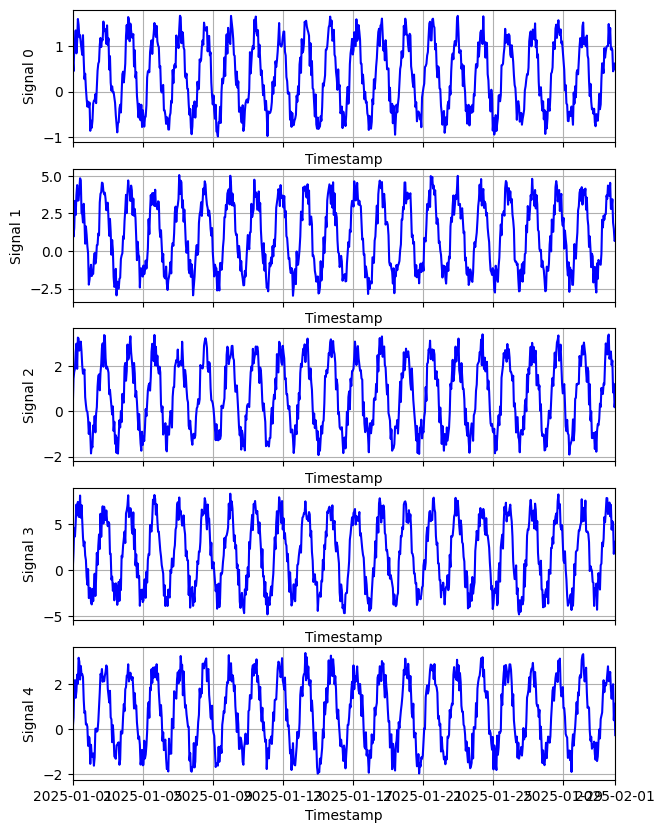

In [24]:
LEVEL_OF_NOISE = 0.7

# Signal data
num_signals = 5
start_date = '2025-01-01'
end_date = '2025-02-01'
timestamps = pd.date_range(start_date,end_date,freq='h')
amplitudes = [1, 3, 2, 5, 2]
freq = 1/11 # In 1/h

# Setting up seed so randomness is always the same with same given signal
rng = np.random.default_rng(2025)

values = np.empty((timestamps.size,num_signals),dtype=float)
time = (timestamps-timestamps[0]).total_seconds()/3600
for s in range(num_signals):
    values[:,s] = amplitudes[s] * np.sin(2*freq*time)
    values[:,s] += LEVEL_OF_NOISE *amplitudes[s] * rng.random(time.size)


orig_signals = pd.DataFrame(values,index=timestamps)
orig_signals.columns = [f'Signal {k}' for k in range(num_signals)]
orig_signals.index = pd.to_datetime(orig_signals.index)

builder = pyfade.DataFrameBuilder(orig_signals)
dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build()

dataset.plot(height=2,width=7);


In [25]:
# Size of the anomalies in hours
size = 24

# Setting up seed so anomalies are always the same when all inputs are the same
rng = np.random.default_rng(2025)

# Anomaly location (# signals with anomaly, start, size)
rand_anomalies = [(2, '2025-01-10', size, []),
                  (4, '2025-01-20', size, []),
                  (1, '2025-01-25', size, [])]

step_anomalies = [(2, '2025-01-13', size, []),
                  (1, '2025-01-28', size, [])]

# Inserting random anomalies
anom_signal = orig_signals.copy()
for num_anomalous,start,size,an_list in rand_anomalies:

    # Getting information, choosing faulty signals and saving this info
    series = rng.choice(num_signals,size=num_anomalous,replace=False)
    an_list.extend(series)

    for s in series:
        col = anom_signal.columns[s]
        anom_signal.loc[pd.date_range(start=start, periods=size, freq='h'),col] += 1 *amplitudes[s] * rng.random(size)

# Inserting step anomalies
for num_anomalous,start,_,an_list in step_anomalies:

    # Getting information, choosing faulty signals and saving this info
    series = rng.choice(num_signals,size=num_anomalous,replace=False)
    an_list.extend(series)

    for s in series:
        col = anom_signal.columns[s]
        anom_signal.loc[pd.date_range(start=start, end=anom_signal.index.max(), freq='h'),col] += 1 *amplitudes[s]


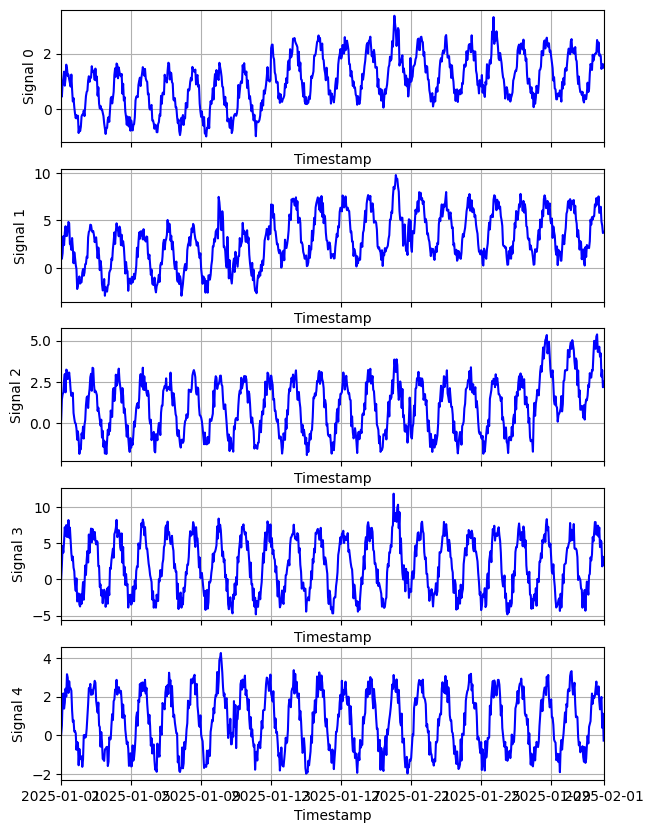

In [26]:
builder = pyfade.DataFrameBuilder(anom_signal)
dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build()

dataset.plot(height=2,width=7);

In [27]:
arima = pyfade.ArimaFit(dataset)
arima.set_order(13,1,13)
arima.set_test_size(1)

In [28]:
x = arima.fit()

c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\sklearn\utils\deprecation.py:151: Fut

c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


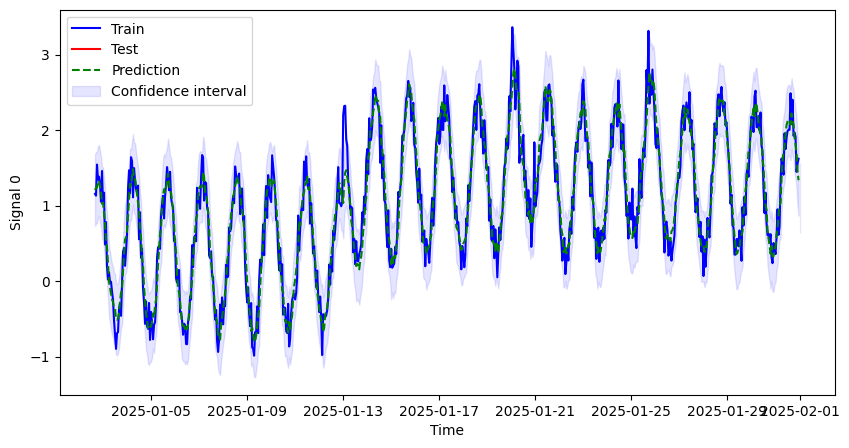

In [29]:
arima.plot_fit()

c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


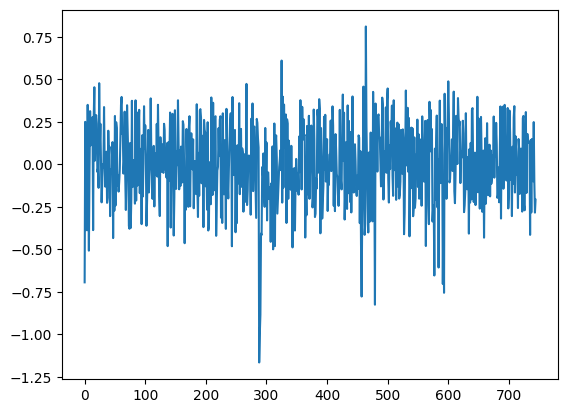

In [30]:
a=arima.get_prediction()
difference = a-dataset.data[0,:]
plt.plot(difference)

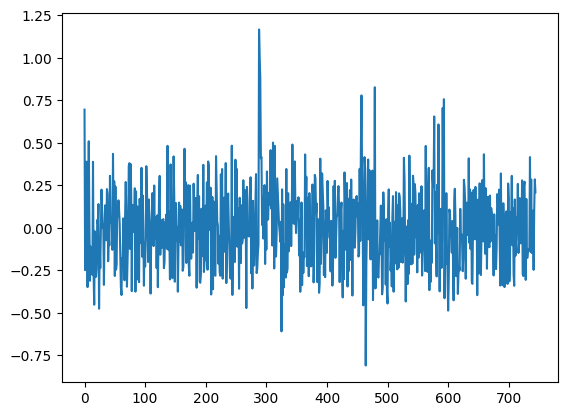

In [31]:
b=arima.get_residual()
plt.plot(b)

In [32]:
SUBSEQ_SIZE = 24
QUANTILE = 0
LEFT_ONLY = True
USE_CUDA = True
SKIP_START=SUBSEQ_SIZE*7

MP_PARAMS ={
    'quantile_threshold': QUANTILE,
    'skip_start': SKIP_START,
    'left_only': LEFT_ONLY,
    'use_cuda': USE_CUDA,
}

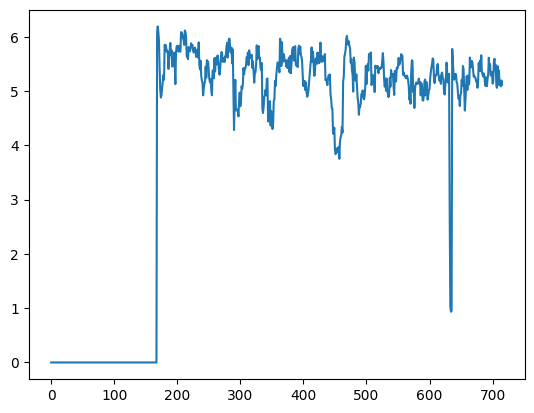

In [33]:
frame = pyfade.DataFrameBuilder(b).build()
window = pyfade.WindowBuilder(frame).set_window_size(30).build()
pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile,window).set_parameters(MP_PARAMS).build()

plt.plot(window.mp.T)